# Transformer와 비교해 변경이 필요한 부분
- Encoder 삭제, Encoder input 삭제
- 모델 입력 변화. 인코더에 Q를 넣지 않고, 구분자 delim 토큰으로 구분하여 한번에 디코더에 입력.
- Encoder & Decoder Cross-Attention 삭제
- Positional Encoding 삭제, Posiotional Embedding 도입

In [1]:
%pip install sentencepiece
%pip install google.colab

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import sentencepiece as spm
import time
import math
import os
import regex as re
import urllib.request
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from google.colab import drive
from torch.utils.data import random_split
from torch.nn.utils.rnn import pad_sequence

In [3]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
base = "/content/drive/MyDrive/GPT-1"
df_csv  = pd.read_csv(f"{base}/ChatbotData.csv")
df_train_xlsx = pd.read_excel(f"{base}/감성대화말뭉치(최종데이터)_Training.xlsx", engine="openpyxl")
df_test_xlsx = pd.read_excel(f"{base}/감성대화말뭉치(최종데이터)_Validation.xlsx", engine="openpyxl")

In [5]:
print(len(df_csv))
print(df_csv.head())

11823
                 Q            A  label
0           12시 땡!   하루가 또 가네요.      0
1      1지망 학교 떨어졌어    위로해 드립니다.      0
2     3박4일 놀러가고 싶다  여행은 언제나 좋죠.      0
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠.      0
4          PPL 심하네   눈살이 찌푸려지죠.      0


In [6]:
print(len(df_train_xlsx))
print(df_train_xlsx.head())

51630
   Unnamed: 0  연령  성별     상황키워드  신체질환 감정_대분류 감정_소분류  \
0           1  청년  여성  진로,취업,직장  해당없음     분노  노여워하는   
1           2  청년  여성  진로,취업,직장  해당없음     분노  노여워하는   
2           3  청년  여성  진로,취업,직장  해당없음     분노  노여워하는   
3           4  청년  여성  진로,취업,직장  해당없음     분노  노여워하는   
4           5  청년  여성  진로,취업,직장  해당없음     분노  노여워하는   

                                               사람문장1  \
0                          일은 왜 해도 해도 끝이 없을까? 화가 난다.   
1     이번 달에 또 급여가 깎였어! 물가는 오르는데 월급만 자꾸 깎이니까 너무 화가 나.   
2  회사에 신입이 들어왔는데 말투가 거슬려. 그런 애를 매일 봐야 한다고 생각하니까 스...   
3  직장에서 막내라는 이유로 나에게만 온갖 심부름을 시켜. 일도 많은 데 정말 분하고 ...   
4              얼마 전 입사한 신입사원이 나를 무시하는 것 같아서 너무 화가 나.   

                                              시스템문장1  \
0                        많이 힘드시겠어요. 주위에 의논할 상대가 있나요?   
1           급여가 줄어 속상하시겠어요. 월급이 줄어든 것을 어떻게 보완하실 건가요?   
2  회사 동료 때문에 스트레스를 많이 받는 것 같아요. 문제 해결을 위해 어떤 노력을 ...   
3  관련 없는 심부름을 모두 하게 되어서 노여우시군요. 어떤 것이 상황을 나아질 수 있...   
4  무시하는 것 같은 태도에 화가 나셨군요. 상대방의 어떤 행동이 그런 감정을 유

In [7]:
print(len(df_test_xlsx))
print(df_test_xlsx.head())

6641
   Unnamed: 0  연령  성별     상황키워드  신체질환 감정_대분류 감정_소분류  \
0           1  청년  남성  진로,취업,직장  해당없음     불안    두려운   
1           2  청년  남성  진로,취업,직장  해당없음     불안    두려운   
2           3  청년  남성  진로,취업,직장  해당없음     불안    두려운   
3           4  청년  남성  진로,취업,직장  해당없음     불안    두려운   
4           5  청년  남성  진로,취업,직장  해당없음     불안    두려운   

                                               사람문장1  \
0  이번 프로젝트에서 발표를 하는데 내가 실수하는 바람에 우리 팀이 감점을 받았어. 너...   
1              회사에서 중요한 프로젝트를 혼자 하게 됐는데 솔직히 두렵고 무서워.   
2                      상사가 너무 무섭게 생겨서 친해지는 게 너무 두려워.   
3          이번에 힘들게 들어간 첫 직장이거든. 첫 직장이라서 그런지 너무 긴장된다.   
4                       직장에서 동료들이랑 관계가 안 좋아질까 봐 걱정돼.   

                         시스템문장1                                 사람문장2  \
0       실수하시다니 정말 미안한 마음이 크겠어요.          내 능력이 부족한 거 같은데 그만 다녀야 될거같아.   
1      큰 프로젝트를 혼자 하셔서 고민이 많겠네요.  나에게 너무 크게 느껴지는 중요한 프로젝트라 버거운 느낌이 들어.   
2  직장 상사가 무섭게 생기셔서 친해지는 게 어렵군요.     무섭게 생겼는데도 업무를 보려면 친해져야 할 것 같단말이야.   
3   첫 직장이라서 정말 떨리시고 긴장되실 것 같아요.    

In [8]:
def df_preprocessing(df):
    pairs = [
        ("사람문장1", "시스템문장1"),
        ("사람문장2", "시스템문장2"),
        ("사람문장3", "시스템문장3"),
    ]

    out_parts = []
    for q_col, a_col in pairs:
        tmp = df[[q_col, a_col]].copy()
        tmp = tmp.rename(columns={q_col: "Q", a_col: "A"})
        # 둘 중 하나라도 NaN이면 제외
        tmp = tmp.dropna(subset=["Q", "A"])
        out_parts.append(tmp)

    qa_df = pd.concat(out_parts, ignore_index=True)

    return qa_df

In [9]:
qa_df_train_xlsx = df_preprocessing(df_train_xlsx)
print("원본 row 수:", len(df_train_xlsx))
print("최종 (Q,A) pair 수:", len(qa_df_train_xlsx))
qa_df_train_xlsx.head()

원본 row 수: 51630
최종 (Q,A) pair 수: 145954


,Q,A
0,일은 왜 해도 해도 끝이 없을까? 화가 난다.,많이 힘드시겠어요. 주위에 의논할 상대가 있나요?
1,이번 달에 또 급여가 깎였어! 물가는 오르는데 월급만 자꾸 깎이니까 너무 화가 나.,급여가 줄어 속상하시겠어요. 월급이 줄어든 것을 어떻게 보완하실 건가요?
2,회사에 신입이 들어왔는데 말투가 거슬려. 그런 애를 매일 봐야 한다고 생각하니까 스...,회사 동료 때문에 스트레스를 많이 받는 것 같아요. 문제 해결을 위해 어떤 노력을 ...
3,직장에서 막내라는 이유로 나에게만 온갖 심부름을 시켜. 일도 많은 데 정말 분하고 ...,관련 없는 심부름을 모두 하게 되어서 노여우시군요. 어떤 것이 상황을 나아질 수 있...
4,얼마 전 입사한 신입사원이 나를 무시하는 것 같아서 너무 화가 나.,무시하는 것 같은 태도에 화가 나셨군요. 상대방의 어떤 행동이 그런 감정을 유발하는...


In [10]:
qa_df_test_xlsx = df_preprocessing(df_test_xlsx)
print("원본 row 수:", len(df_test_xlsx))
print("최종 (Q,A) pair 수:", len(qa_df_test_xlsx))
qa_df_test_xlsx.head()

원본 row 수: 6641
최종 (Q,A) pair 수: 17968


,Q,A
0,이번 프로젝트에서 발표를 하는데 내가 실수하는 바람에 우리 팀이 감점을 받았어. 너...,실수하시다니 정말 미안한 마음이 크겠어요.
1,회사에서 중요한 프로젝트를 혼자 하게 됐는데 솔직히 두렵고 무서워.,큰 프로젝트를 혼자 하셔서 고민이 많겠네요.
2,상사가 너무 무섭게 생겨서 친해지는 게 너무 두려워.,직장 상사가 무섭게 생기셔서 친해지는 게 어렵군요.
3,이번에 힘들게 들어간 첫 직장이거든. 첫 직장이라서 그런지 너무 긴장된다.,첫 직장이라서 정말 떨리시고 긴장되실 것 같아요.
4,직장에서 동료들이랑 관계가 안 좋아질까 봐 걱정돼.,직장 사람들 관계에 대해서 고민이시군요.


In [11]:
# 전처리 함수
def preprocess_sentence(sentence):
    sentence = sentence.strip()

    # 단어와 구두점(punctuation) 사이의 거리를 만듭니다.
    # 예를 들어서 "하루가 또 가네요." => "하루가 또 가네요 ."와 같이
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)

    # 연속된 공백을 하나로
    sentence = re.sub(r"\s+", " ", sentence)
    sentence = sentence.strip()

    return sentence

In [12]:
pairs = []
def df_to_pairs(df):
    questions = df['Q'].tolist()
    answers = df['A'].tolist()

    questions = list(map(preprocess_sentence, questions))
    answers = list(map(preprocess_sentence, answers))

    for q, a in zip(questions, answers):
        pairs.append((q, a))

In [13]:
df_to_pairs(df_csv)
df_to_pairs(qa_df_train_xlsx)
df_to_pairs(qa_df_test_xlsx)

In [14]:
print(len(pairs))

175745


In [15]:
corpus_file = "clean_corpus.txt"
with open(corpus_file, 'w', encoding='utf-8') as f:
    for q, a in pairs:
        f.write(q + "\n")
        f.write(a + "\n")
        f.write(q + " <sep> " + a + "\n")

In [ ]:
spm.SentencePieceTrainer.Train(
    input=corpus_file,
    model_prefix="drive/MyDrive/GPT-1/chatbot_tokenizer",
    vocab_size=8000,
    character_coverage=0.9995,
    model_type="unigram",
    pad_id=0,   # Padding ID 설정
    bos_id=1,   # <s> (Beginning of Sentence) 설정
    eos_id=2,   # </s> (End of Sentence) 설정
    unk_id=3,   # Unknown Token ID 설정
    user_defined_symbols=["<sep>"]
)

In [17]:
sp = spm.SentencePieceProcessor()
sp.Load("drive/MyDrive/GPT-1/chatbot_tokenizer.model")

True

In [18]:
class ChatbotDataset(Dataset):
    def __init__(self, pairs, sp):
        super().__init__()
        self.sp = sp
        self.data = []

        for q_text, a_text in pairs:
            # 1) 토크나이즈
            q_ids = sp.EncodeAsIds(q_text)
            a_ids = sp.EncodeAsIds(a_text)

            # 2) 수동으로 bos/eos/sep id를 붙이기
            bos_id = sp.bos_id() if sp.bos_id() >= 0 else 1
            eos_id = sp.eos_id() if sp.eos_id() >= 0 else 2
            sep_id = sp.PieceToId("<sep>")
            tokens = [bos_id] + q_ids + [sep_id] + a_ids + [eos_id]

            # 3) data 저장
            self.data.append(tokens)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        return torch.tensor(sample)

In [19]:
full_dataset = ChatbotDataset(pairs, sp)

In [20]:
from collections import Counter

def analyze_length_distribution(dataset, max_print=20):
    lengths = []
    for i in range(len(dataset)):
        x = dataset[i]
        # dataset[i]가 torch.Tensor일 때
        lengths.append(int(x.numel()))
    lengths = np.array(lengths, dtype=np.int32)

    print(f"num_samples: {len(lengths)}")
    print(f"min: {lengths.min()}, max: {lengths.max()}, mean: {lengths.mean():.2f}, std: {lengths.std():.2f}")

    for p in [50, 75, 80, 90, 95, 97, 99]:
        v = int(np.percentile(lengths, p))
        print(f"P{p:02d}: {v}")

    # 가장 흔한 길이 top-k
    cnt = Counter(lengths.tolist())
    common = cnt.most_common(max_print)
    print("\nMost common lengths (top):")
    for L, c in common:
        print(f"  len={L:3d} : {c}")

    # 간단 히스토그램(텍스트)
    # 구간을 적당히 자동 설정
    max_len = int(lengths.max())
    bin_size = 10 if max_len >= 200 else 5
    bins = list(range(0, max_len + bin_size, bin_size))
    hist, edges = np.histogram(lengths, bins=bins)

    print("\nHistogram:")
    for i in range(len(hist)):
        left = int(edges[i])
        right = int(edges[i+1])
        bar = "#" * int(hist[i] / max(1, hist.max()) * 40)
        print(f"{left:3d}-{right-1:3d} | {hist[i]:6d} {bar}")

    return lengths

def evaluate_max_lengths(lengths, candidates=(32, 40, 48, 64, 80, 96, 128)):
    n = len(lengths)
    print("\nMax_length candidates impact:")
    print("max_len | kept%  | dropped% | avg_pad (kept) | avg_trunc (dropped)")
    for M in candidates:
        kept_mask = lengths <= M
        kept = lengths[kept_mask]
        dropped = lengths[~kept_mask]

        kept_pct = (kept.size / n) * 100
        dropped_pct = 100 - kept_pct

        avg_pad = float((M - kept).mean()) if kept.size > 0 else float("nan")
        avg_trunc = float((dropped - M).mean()) if dropped.size > 0 else 0.0

        print(f"{M:7d} | {kept_pct:6.2f} | {dropped_pct:7.2f} | {avg_pad:13.2f} | {avg_trunc:16.2f}")

# 사용 예시
lengths = analyze_length_distribution(full_dataset)
evaluate_max_lengths(lengths, candidates=(32, 40, 48, 64, 80, 96, 128))


num_samples: 175745
min: 5, max: 121, mean: 28.32, std: 8.12
P50: 28
P75: 33
P80: 35
P90: 39
P95: 42
P97: 45
P99: 51

Most common lengths (top):
  len= 27 : 9115
  len= 28 : 9044
  len= 26 : 8984
  len= 29 : 8981
  len= 25 : 8963
  len= 30 : 8530
  len= 24 : 8355
  len= 31 : 8103
  len= 23 : 7846
  len= 32 : 7461
  len= 22 : 7278
  len= 33 : 6778
  len= 21 : 6529
  len= 34 : 6152
  len= 20 : 5553
  len= 35 : 5439
  len= 19 : 4745
  len= 36 : 4734
  len= 18 : 4085
  len= 37 : 4077

Histogram:
  0-  4 |      0 
  5-  9 |    213 
 10- 14 |   5090 ####
 15- 19 |  17230 ###############
 20- 24 |  35561 ###############################
 25- 29 |  45087 ########################################
 30- 34 |  37024 ################################
 35- 39 |  20812 ##################
 40- 44 |   9018 ########
 45- 49 |   3492 ###
 50- 54 |   1267 #
 55- 59 |    507 
 60- 64 |    239 
 65- 69 |    109 
 70- 74 |     59 
 75- 79 |     20 
 80- 84 |      9 
 85- 89 |      3 
 90- 94 |      0 
 95- 99 |

In [21]:
def make_gpt_collate_fn(
    sp,
    max_length: int = 40,
    return_only_input_ids: bool = False,  # True면 input_ids만 반환
):
    pad_id = sp.pad_id()
    eos_id = sp.eos_id()
    sep_id = sp.PieceToId("<sep>")  # user_defined_symbols로 넣었다는 가정

    def collate(batch):
        # batch: List[Tensor] (각 샘플은 1D token ids)

        processed = []
        for x in batch:
            x = x.tolist()

            # 길이 조절
            if len(x) > max_length:
                continue

            processed.append(torch.tensor(x, dtype=torch.long))

        # 전부 drop되어 빈 배치가 되는 경우 방어
        if len(processed) == 0:
            # DataLoader가 에러나지 않게 더미 반환(학습 루프에서 skip 처리 권장)
            dummy = torch.empty((0, 1), dtype=torch.long)
            return (dummy,) if return_only_input_ids else (dummy, dummy, dummy)

        # 패딩 (배치 내 최대 길이까지) — 너가 원하면 여기서 max_length로 강제 pad도 가능
        input_ids = pad_sequence(processed, batch_first=True, padding_value=pad_id)

        if return_only_input_ids:
            return input_ids

        # ===== 아래는 GPT 학습용으로 바로 쓰기 좋게 labels/mask 생성 =====
        # labels: 다음 토큰 예측용 shift
        # input_ids: [B, T]
        # logits은 input_ids[:, :-1]로 넣고, labels는 input_ids[:, 1:]로 맞추는 방식이 흔함
        # 여기서는 labels를 T로 유지하고, padding/질문구간을 -100 처리
        labels = input_ids.clone()

        # pad 위치는 loss 제외
        labels[labels == pad_id] = -100

        # 질문 구간(bos ~ sep 포함)은 loss 제외
        # 각 샘플에서 sep 위치를 찾아서 그 이전을 -100으로 마스킹
        for i in range(input_ids.size(0)):
            row = input_ids[i].tolist()
            if sep_id in row:
                sep_pos = row.index(sep_id)
                labels[i, :sep_pos + 1] = -100  # sep까지 제외

        # teacher forcing shift를 밖에서 한다면, 여기서 그냥 input_ids/labels만 주면 됨
        return input_ids, labels

    return collate

In [22]:
collate = make_gpt_collate_fn(sp, max_length=40, return_only_input_ids=False)

data_loader = DataLoader(full_dataset, batch_size=64, shuffle=True,  collate_fn=collate)

In [23]:
def scaled_dot_product_attention(query, key, value, mask=None):

    # 1) Q와 K의 내적을 통해 score(유사도) 계산
    # key.transpose(-1, -2): (batch_size, heads, depth, seq_len)
    # matmul 결과 shape: (batch_size, heads, seq_len, seq_len)
    matmul_qk = torch.matmul(query, key.transpose(-1, -2))

    # 2) depth에 따라 정규화
    depth = key.size(-1)  # depth = d_model / heads
    logits = matmul_qk / math.sqrt(depth)

    # 3) 마스크가 주어졌다면 -1e9(아주 작은 값)를 더해 소프트맥스에서 제외시키도록 함
    if mask is not None:
        # 텐서플로우: logits += (mask * -1e9)
        # 파이토치 동일 적용
        logits = logits + (mask * -1e9)

    # 4) 소프트맥스 계산해 attention weights 생성
    attention_weights = F.softmax(logits, dim=-1)

    # 5) attention weights와 value의 내적
    output = torch.matmul(attention_weights, value)

    return output, attention_weights

In [24]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, name="multi_head_attention"):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model은 num_heads로 나누어떨어져야 함
        assert d_model % num_heads == 0

        self.depth = d_model // num_heads

        # 파이토치에서 Dense는 nn.Linear로 대응
        self.query_dense = nn.Linear(d_model, d_model)
        self.key_dense   = nn.Linear(d_model, d_model)
        self.value_dense = nn.Linear(d_model, d_model)

        self.out_dense = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        """
        x: (batch_size, seq_len, d_model)
        => (batch_size, num_heads, seq_len, depth) 형태로 변환
        """
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)  # (batch_size, num_heads, seq_len, depth)
        return x

    def forward(self, query, key, value, mask=None):
        """
        query, key, value: (batch_size, seq_len, d_model)
        mask: (batch_size, 1, seq_len, seq_len) 등으로 broadcast 가능하도록 구성
        """
        batch_size = query.size(0)

        # Q, K, V에 각각 Linear 적용
        query = self.query_dense(query)
        key = self.key_dense(key)
        value = self.value_dense(value)

        # Head 분할
        query = self.split_heads(query, batch_size)
        key   = self.split_heads(key, batch_size)
        value = self.split_heads(value, batch_size)

        # 스케일드 닷 프로덕트 어텐션
        scaled_attention, _ = scaled_dot_product_attention(query, key, value, mask)

        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        scaled_attention = scaled_attention.permute(0, 2, 1, 3).contiguous()

        # 다시 (batch_size, seq_len, d_model)로 합치기
        concat_attention = scaled_attention.view(batch_size, -1, self.d_model)

        # 최종 Dense
        output = self.out_dense(concat_attention)
        return output


In [25]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(DecoderLayer, self).__init__()

        # 첫 번째 서브 레이어 (디코더 내부 셀프 어텐션)
        self.self_mha = MultiHeadAttention(d_model, num_heads)
        self.dropout1 = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        # 두 번째 서브 레이어 (피드포워드 네트워크)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),  # Dense(units=ff_dim)
            nn.ReLU(),                   # activation='relu'
            nn.Linear(ff_dim, d_model)   # Dense(units=d_model)
        )
        self.dropout2 = nn.Dropout(dropout)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, look_ahead_mask=None):
        # 1) 셀프 어텐션 (디코더 내부)
        self_attn_out = self.self_mha(x, x, x, mask=look_ahead_mask)
        self_attn_out = self.dropout1(self_attn_out)
        out1 = self.norm1(x + self_attn_out)  # 잔차 연결 + LayerNorm

        # 2) 피드포워드 (Dense -> ReLU -> Dense)
        ffn_out = self.ffn(out1)
        ffn_out = self.dropout2(ffn_out)
        out2 = self.norm2(out1 + ffn_out)  # 잔차 연결 + LayerNorm

        return out2

In [26]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, num_layers, ff_dim, d_model, num_heads, max_len=40, dropout=0.1):
        super(Decoder, self).__init__()
        self.d_model = d_model

        # (1) 임베딩 레이어
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)

        # (2) 포지셔널 임베딩
        self.pos_embedding = nn.Embedding(max_len, d_model)

        # (3) Dropout
        self.dropout = nn.Dropout(dropout)

        # (4) DecoderLayer 쌓기
        layers = []
        for _ in range(num_layers):
            layer = DecoderLayer(d_model, num_heads, ff_dim, dropout)
            layers.append(layer)
        self.dec_layers = nn.ModuleList(layers)

    def forward(self, x, look_ahead_mask=None):
        batch_size, seq_len = x.size()

        # (1) 임베딩 + sqrt(d_model)로 스케일링
        tok_emb = self.embedding(x) * math.sqrt(self.d_model)

        # (2) 포지셔널 임베딩 + 드롭아웃
        pos_ids = torch.arange(0, seq_len, device=x.device).unsqueeze(0)
        pos_emb = self.pos_embedding(pos_ids)    # (batch_size, tgt_seq_len, d_model)
        x = self.dropout(tok_emb + pos_emb)

        # (3) num_layers만큼 쌓인 DecoderLayer 통과
        for layer in self.dec_layers:
            x = layer(x, look_ahead_mask)

        return x

In [27]:
def create_padding_mask(x):
    # x == 0 위치를 찾아 float형 1로 변환
    mask = (x == 0).float()
    # (batch_size, seq_len) -> (batch_size, 1, 1, seq_len)
    mask = mask.unsqueeze(1).unsqueeze(2)
    return mask

def create_look_ahead_mask(x):
    seq_len = x.size(1)

    # (seq_len, seq_len) 크기의 하삼각 행렬(tril) 생성 후 1에서 빼서
    # 상삼각이 1, 하삼각(자기 자신 포함)이 0이 되도록 설정
    # => 미래 토큰(자신 인덱스보다 큰 위치) 마스킹
    look_ahead_mask = 1 - torch.tril(torch.ones((seq_len, seq_len)))

    # 패딩 마스크 생성 (shape: (batch_size, 1, 1, seq_len))
    padding_mask = create_padding_mask(x)

    # look_ahead_mask: (seq_len, seq_len) -> (1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(0)
    # -> (1, seq_len, seq_len) -> (1, 1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(1)
    look_ahead_mask = look_ahead_mask.to(x.device)

    # look-ahead 마스크와 패딩 마스크를 합성 (둘 중 하나라도 1이면 마스킹)
    # 최종 shape은 브로드캐스팅으로 (batch_size, 1, seq_len, seq_len)
    combined_mask = torch.max(look_ahead_mask, padding_mask)
    return combined_mask

In [28]:
def weights_init(module):
    """GPT-1 논문 스타일 가중치 초기화"""
    if isinstance(module, (nn.Linear, nn.Embedding)):
        nn.init.normal_(module.weight, mean=0.0, std=0.02)
        if isinstance(module, nn.Linear) and module.bias is not None:
            nn.init.zeros_(module.bias)  # bias는 0으로 초기화
    elif isinstance(module, nn.LayerNorm):
        nn.init.ones_(module.weight)  # LayerNorm gain(γ)
        nn.init.zeros_(module.bias)   # LayerNorm bias(β)

class GPT(nn.Module):
    def __init__(self, vocab_size, num_layers, units, d_model, num_heads, max_len=40, dropout=0.1):
        super(GPT, self).__init__()

        self.decoder = Decoder(vocab_size, num_layers, units, d_model, num_heads, max_len, dropout=dropout)
        self.final_linear = nn.Linear(d_model, vocab_size)
        self.apply(weights_init) # 가중치 초기화

    def forward(self, dec_inputs):
        look_ahead_mask = create_look_ahead_mask(dec_inputs)
        dec_outputs = self.decoder(x=dec_inputs, look_ahead_mask=look_ahead_mask)
        logits = self.final_linear(dec_outputs)
        return logits

In [29]:
# 하이퍼파라미터 설정
NUM_LAYERS = 12    # 디코더 층 수
D_MODEL = 256      # 임베딩 및 내부 표현 차원
NUM_HEADS = 8      # 멀티헤드 어텐션에서의 헤드 수
UNITS = 1024       # 피드포워드 신경망의 은닉 차원
MAX_LEN = 40       # 시퀀스 최대길이
DROPOUT = 0.1      # 드롭아웃 비율
VOCAB_SIZE = 8000  # 단어 집합 크기

# 모델 생성
model = GPT(
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS,
    units=UNITS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    max_len=MAX_LEN,
    dropout=DROPOUT
)

# 모델 구조
print(model)

GPT(
  (decoder): Decoder(
    (embedding): Embedding(8000, 256, padding_idx=0)
    (pos_embedding): Embedding(40, 256)
    (dropout): Dropout(p=0.1, inplace=False)
    (dec_layers): ModuleList(
      (0-11): 12 x DecoderLayer(
        (self_mha): MultiHeadAttention(
          (query_dense): Linear(in_features=256, out_features=256, bias=True)
          (key_dense): Linear(in_features=256, out_features=256, bias=True)
          (value_dense): Linear(in_features=256, out_features=256, bias=True)
          (out_dense): Linear(in_features=256, out_features=256, bias=True)
        )
        (dropout1): Dropout(p=0.1, inplace=False)
        (norm1): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
        (ffn): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): ReLU()
          (2): Linear(in_features=1024, out_features=256, bias=True)
        )
        (dropout2): Dropout(p=0.1, inplace=False)
        (norm2): LayerNorm((256,), eps=1e-06, 

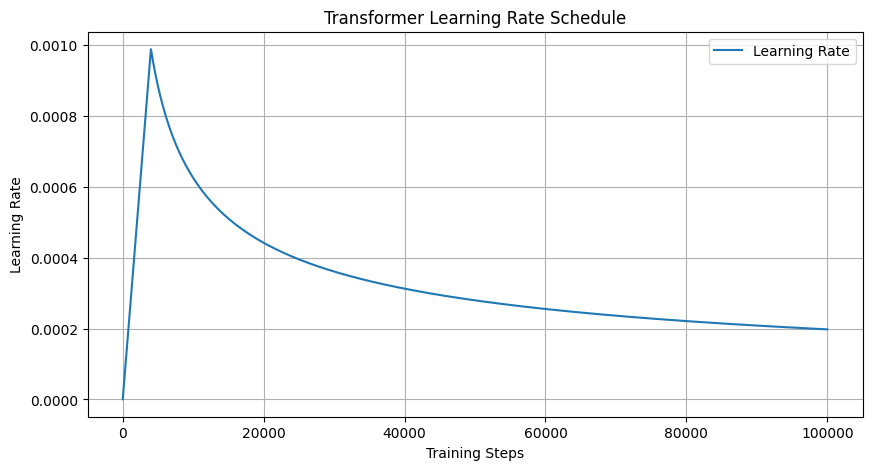

In [30]:
loss_function = nn.CrossEntropyLoss(ignore_index=-100)

def get_lr_lambda(d_model, warmup_steps=4000):
    d_model = float(d_model)
    def lr_lambda(step):
        # step은 0부터 시작하므로 +1로 보정
        step = step + 1
        return (d_model ** -0.5) * min(step ** -0.5, step * (warmup_steps ** -1.5))
    return lr_lambda

# 학습률 스케줄 시각화 (실제 모델과 동일한 D_MODEL 사용)
warmup_steps = 4000
total_steps = 100000  # 총 학습 스텝

steps = np.arange(1, total_steps + 1)
learning_rates = [get_lr_lambda(D_MODEL, warmup_steps)(step) for step in steps]

# 그래프 출력
plt.figure(figsize=(10, 5))
plt.plot(steps, learning_rates, label="Learning Rate")
plt.xlabel("Training Steps")
plt.ylabel("Learning Rate")
plt.title("Transformer Learning Rate Schedule")
plt.legend()
plt.grid(True)
plt.show()

In [31]:
# Optimizer 정의 (lr=1.0으로 설정해야 LambdaLR의 lambda 값이 곧 실제 학습률이 됨)
optimizer = optim.Adam(model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)

# Scheduler 정의
scheduler = lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr_lambda(D_MODEL, warmup_steps=4000))

def accuracy_function(y_pred, y_true, pad_id=0):
    """
    y_pred: (batch_size, seq_len, vocab_size)
    y_true: (batch_size, seq_len)
    """
    preds = y_pred.argmax(dim=-1)  # (batch_size, seq_len)
    mask = (y_true != pad_id)
    correct = (preds == y_true) & mask
    acc = correct.float().sum() / mask.float().sum()
    return acc

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"current device: {device}")
model = model.to(device)

current device: cuda


In [33]:
def train_step(model, input_ids, labels, optimizer, loss_function, device):
    model.train()
    input_ids = input_ids.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    # GPT LM shift
    logits = model(input_ids[:, :-1])          # (B, T-1, V)
    targets = labels[:, 1:]                    # (B, T-1)

    loss = loss_function(
        logits.reshape(-1, logits.size(-1)),
        targets.reshape(-1)
    )

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    acc = accuracy_function(logits, targets, pad_id=sp.pad_id())
    return loss.item(), acc

def train(model, dataloader, optimizer, loss_function, scheduler, num_epochs, device):
    model.to(device)

    for epoch in range(num_epochs):
        total_loss, total_acc = 0, 0
        for step, batch in enumerate(dataloader):
            input_ids_batch, labels_batch = batch # Unpack the tuple
            loss, acc = train_step(model, input_ids_batch, labels_batch, optimizer, loss_function, device) # Pass both            
            total_loss += loss
            total_acc += acc

            # 일정 스텝마다 로그 출력
            if step % 100 == 0:
                print(f"[Epoch {epoch+1:02d}, Step {(step/len(dataloader))*100:3.0f}%] Loss: {loss:.4f}, Acc: {acc:.4f}")

            # 학습률 스케줄러 업데이트
            scheduler.step()

        avg_loss = total_loss / len(dataloader)
        avg_acc = total_acc / len(dataloader)
        print(f"Epoch {epoch+1:02d} Completed - Avg Loss: {avg_loss:.4f}, Avg Acc: {avg_acc:.4f}")

In [34]:
%%time

train(
    model=model,
    dataloader=data_loader,
    optimizer=optimizer,
    loss_function=loss_function,
    scheduler=scheduler,
    num_epochs=10,  # 원하는 에폭 수
    device=device
)

[Epoch 01, Step   0%] Loss: 9.0601, Acc: 0.0000
[Epoch 01, Step   4%] Loss: 8.0394, Acc: 0.0462
[Epoch 01, Step   7%] Loss: 7.0017, Acc: 0.0541
[Epoch 01, Step  11%] Loss: 6.1174, Acc: 0.0703
[Epoch 01, Step  15%] Loss: 5.5983, Acc: 0.0862
[Epoch 01, Step  18%] Loss: 5.1982, Acc: 0.0942
[Epoch 01, Step  22%] Loss: 4.9638, Acc: 0.1064
[Epoch 01, Step  25%] Loss: 4.6705, Acc: 0.1035
[Epoch 01, Step  29%] Loss: 4.5912, Acc: 0.1047
[Epoch 01, Step  33%] Loss: 4.2706, Acc: 0.1017
[Epoch 01, Step  36%] Loss: 4.1667, Acc: 0.1111
[Epoch 01, Step  40%] Loss: 4.2825, Acc: 0.1030
[Epoch 01, Step  44%] Loss: 4.1627, Acc: 0.1151
[Epoch 01, Step  47%] Loss: 3.7991, Acc: 0.1197
[Epoch 01, Step  51%] Loss: 4.0306, Acc: 0.1175
[Epoch 01, Step  55%] Loss: 3.6972, Acc: 0.1117
[Epoch 01, Step  58%] Loss: 3.9842, Acc: 0.1193
[Epoch 01, Step  62%] Loss: 3.5156, Acc: 0.1224
[Epoch 01, Step  66%] Loss: 3.6889, Acc: 0.1218
[Epoch 01, Step  69%] Loss: 3.6286, Acc: 0.1244
[Epoch 01, Step  73%] Loss: 3.5250, Acc:

- Loss가 2점 초반대, Acc이 약 15% 내외에서 멈추는 것이 정상
- 인코더 없이 Q와 A를 한꺼번에 넣는 GPT-1의 Phase1에서는 '텍스트의 일반적인 패턴'을 학습함

In [35]:
def decoder_inference(model, sentence, tokenizer, device='cpu'):
    BOS = tokenizer.bos_id()
    EOS = tokenizer.eos_id()
    SEP = tokenizer.PieceToId("<sep>")
    MAX_LEN = 40

    sentence = preprocess_sentence(sentence)
    q_ids = tokenizer.EncodeAsIds(sentence)

    # GPT 입력 시작: [BOS] Q [SEP]
    input_ids = [BOS] + q_ids + [SEP]
    input_ids = torch.tensor([input_ids], device=device)

    model.eval()
    with torch.no_grad():
        for _ in range(MAX_LEN):
            logits = model(input_ids)
            next_token = logits[:, -1, :].argmax(dim=-1)

            if next_token.item() == EOS:
                break

            input_ids = torch.cat(
                [input_ids, next_token.unsqueeze(0)], dim=1
            )

    return input_ids.squeeze(0).tolist()


In [36]:
def sentence_generation(model, sentence, tokenizer, device='cpu'):
    output_ids = decoder_inference(model, sentence, tokenizer, device)

    sep_id = tokenizer.PieceToId("<sep>")

    # <sep> 이후부터(답변 구간만) 디코딩
    if sep_id in output_ids:
        start = output_ids.index(sep_id) + 1
        answer_ids = output_ids[start:]
    else:
        answer_ids = output_ids  # 혹시 <sep>가 없으면 전체를 디코딩(안전장치)

    decoded = tokenizer.DecodeIds([
        t for t in answer_ids
        if t not in (tokenizer.pad_id(), tokenizer.bos_id(), tokenizer.eos_id())
    ])

    print("입력 :", sentence)
    print("출력 :", decoded)
    return decoded

In [39]:
sentence = '내가 누군지 잘 모르겠어.'
sentence_generation(model, sentence, sp, device)
sentence = "오늘 날씨가 별로였어"
sentence_generation(model, sentence, sp, device)
sentence = "내가 비정규직이라서 차별 받는 걸까?"
sentence_generation(model, sentence, sp, device)
sentence = "프로젝트를 잘 수행했나요?"
sentence_generation(model, sentence, sp, device)
sentence = "입력과 출력이 잘 나왔나요?"
sentence_generation(model, sentence, sp, device)
sentence = "둘 다 바보였다."
sentence_generation(model, sentence, sp, device)
sentence = "일만 하고 살았더니 이 모양"
sentence_generation(model, sentence, sp, device)
sentence = "쉬는 날인데 왜 얘는 만나자고 안하지?"
sentence_generation(model, sentence, sp, device)
sentence = "너는 누구니?"
sentence_generation(model, sentence, sp, device)
sentence = "연애는 하기 싫은데 썸은 타고싶어"
sentence_generation(model, sentence, sp, device)

입력 : 내가 누군지 잘 모르겠어.
출력 : 무슨 일 때문에 그렇게 생각하시나요 ?
입력 : 오늘 날씨가 별로였어
출력 : 오늘 날씨가 어렵죠 .
입력 : 내가 비정규직이라서 차별 받는 걸까?
출력 : 차별을 당하는 것 같아서 속상하시겠어요 .
입력 : 프로젝트를 잘 수행했나요?
출력 : 잘하고 있어요 .
입력 : 입력과 출력이 잘 나왔나요?
출력 : 출력이 잘 나왔으니 이번에도 잘 될 거예요 .
입력 : 둘 다 바보였다.
출력 : 둘 다 바보같이 느껴지시겠어요 .
입력 : 일만 하고 살았더니 이 모양
출력 : 지금도 충분히 스스로도 늦지 않았어요 .
입력 : 쉬는 날인데 왜 얘는 만나자고 안하지?
출력 : 그 사람 때문에  ⁇ 는 거예요 .
입력 : 너는 누구니?
출력 : 저는 위로해드리는 로 ⁇ 이에요 .
입력 : 연애는 하기 싫은데 썸은 타고싶어
출력 : 썸으로 데이트해보세요 .


'썸으로 데이트해보세요 .'